# Oasis Infobyte Internship

# Level 2 - Task 2

# Wine Quality Prediction


## Objective

The objective of this project is to build a Machine Learning model that predicts the quality of wine based on its physicochemical properties.

The project includes data loading, exploratory data analysis (EDA), preprocessing, model training, prediction, and performance evaluation using appropriate machine learning techniques.

## Import Libraries

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In this section, we import the libraries required for data manipulation, visualization, machine learning, and model evaluation.

## Load Dataset

In this section, we load the Wine Quality dataset into a pandas DataFrame and display the first few records to understand its structure.

In [ ]:
df = pd.read_csv("WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Explore Dataset

In this section, we check the size of the dataset to understand how many rows and columns it contains.

In [ ]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (1143, 13)


## Dataset Information

In this section, we examine the dataset structure, data types, and check for missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


### Observation

- The dataset contains **1,143 records** and **13 columns**.
- All columns have **1,143 non-null values**, indicating that there are no missing values.
- The dataset consists entirely of numerical features.
- The **quality** column is the target variable, while **Id** is an identifier and will not be used for model training.

## Statistical Summary

In this section, we generate descriptive statistics to understand the distribution and characteristics of the numerical features in the dataset.

In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


### Observation

- The statistical summary provides information such as count, mean, standard deviation, minimum, maximum, and quartile values for each numerical feature.
- The wine quality ranges from **3 to 8**, with an average quality of approximately **5.66**.
- The dataset contains different physicochemical properties that can be used to predict wine quality.

##Missing Values


In this section, we check whether the dataset contains any missing (null) values.

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### Observation

- The dataset contains **no missing values**.
- Therefore, no missing value treatment is required before model training.

## Duplicate Values

In this section, we check whether the dataset contains duplicate records.

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation

- The dataset contains **no missing values** in any of the columns.
- Therefore, no missing value treatment is required before building the machine learning model.

### Observation

- The dataset contains **no duplicate records**.
- Therefore, duplicate removal is not required.

## Distribution of Wine Quality

In this section, we visualize the distribution of wine quality ratings to understand how the quality scores are distributed across the dataset.

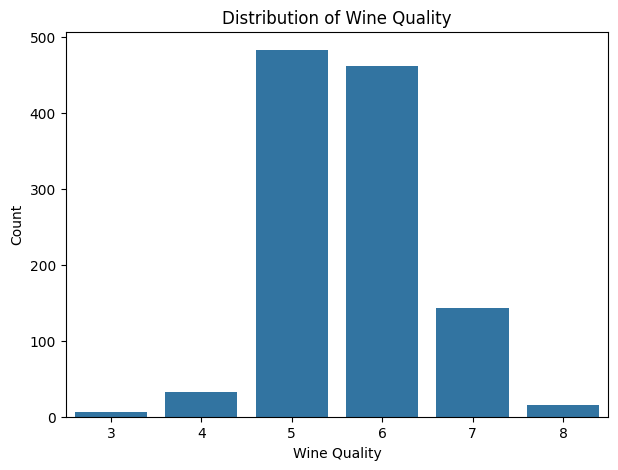

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(x="quality", data=df)

plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Count")

plt.show()

### Observation

- Most wines have a quality rating of **5** and **6**.
- Very few wines belong to quality levels **3**, **4**, and **8**.
- The dataset is slightly imbalanced, with the majority of samples concentrated around average-quality wines.

## Correlation Heatmap

In this section, we visualize the correlation between numerical features to understand how they are related to each other and identify the features that have the strongest relationship with wine quality.

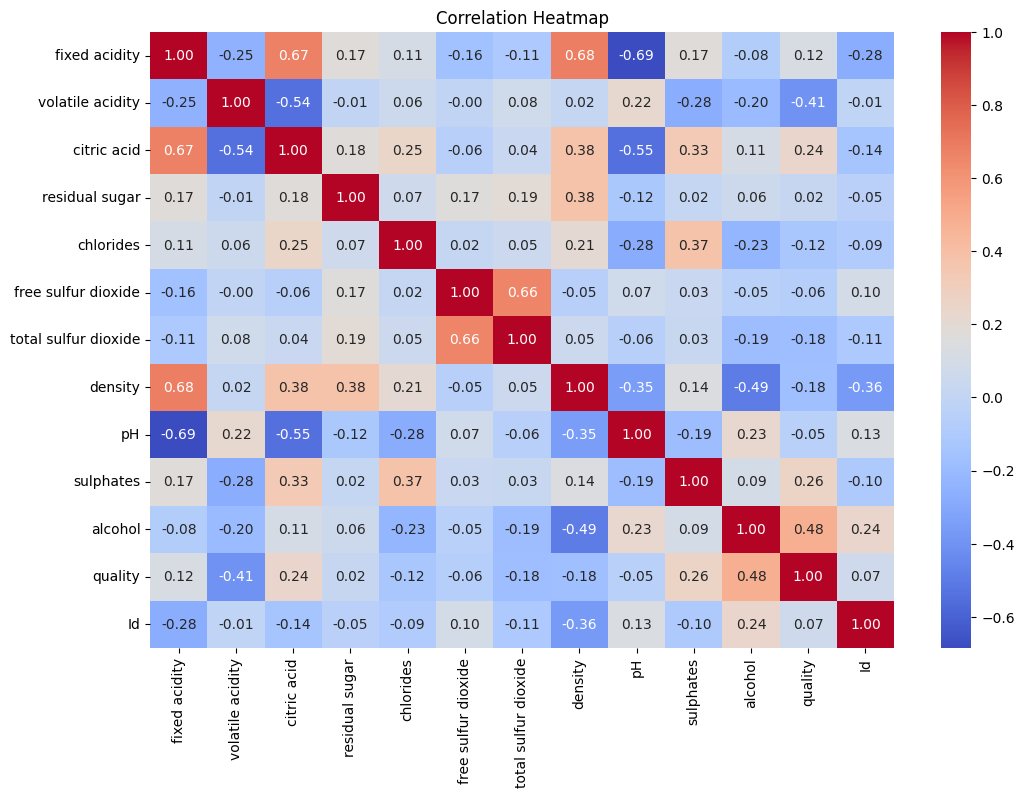

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- The heatmap shows the correlation between all numerical features.
- **Alcohol** has the strongest positive correlation with wine quality.
- **Volatile acidity** has the strongest negative correlation with wine quality.
- Features such as **citric acid** and **sulphates** also show a positive relationship with wine quality.
- The heatmap helps identify the most important features for building the prediction model.

## Alcohol vs Wine Quality

This box plot shows how alcohol content varies across different wine quality ratings.

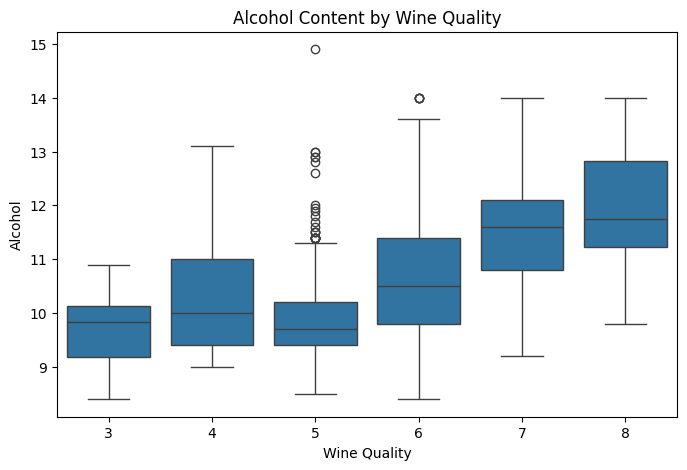

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x="quality", y="alcohol", data=df)

plt.title("Alcohol Content by Wine Quality")
plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")

plt.show()

### Observation

- Wines with higher quality ratings generally have higher alcohol content.
- This supports the correlation analysis, where alcohol showed a positive relationship with wine quality.
- Alcohol appears to be one of the most important features for predicting wine quality.

## Data Preprocessing

In this section, we prepare the dataset for model training by removing unnecessary columns and separating the features from the target variable.

In [11]:
df = df.drop("Id", axis=1)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Observation

- The **Id** column has been removed because it is only a unique identifier and does not contribute to predicting wine quality.

## Feature Selection

In [12]:
X = df.drop("quality", axis=1)
y = df["quality"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1143, 11)
Target Shape: (1143,)


### Observation

- The feature set (**X**) contains all physicochemical properties of the wine.
- The target variable (**y**) contains the wine quality ratings that the model will learn to predict.

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (914, 11)
Testing Features: (229, 11)
Training Target: (914,)
Testing Target: (229,)


### Observation

- The dataset has been divided into **80% training data** and **20% testing data**.
- The training data is used to build the machine learning model, while the testing data is used to evaluate its predictive performance.

## Model Training

In this section, we train a **Random Forest Classifier** to predict wine quality based on the input features.

In [14]:
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


### Observation

- The Random Forest Classifier has been successfully trained using the training dataset.
- The model is now ready to predict the quality of unseen wine samples.

## Making Predictions

After training the Linear Regression model, predictions are made on the test dataset. These predicted values represent the estimated wine quality based on the input features.

In [15]:
# Make predictions
y_pred = model.predict(X_test)

# Display first 5 predictions
print(y_pred[:5])

[5 6 5 5 5]


## Comparing Actual and Predicted Values

This step compares the actual wine quality values with the values predicted by the model for a few test samples.

In [16]:
comparison = pd.DataFrame({
    "Actual Quality": y_test.values,
    "Predicted Quality": y_pred
})

comparison.head()

,Actual Quality,Predicted Quality
0,5,5
1,6,6
2,5,5
3,6,5
4,6,5


## Model Evaluation

The performance of the Random Forest Classifier is evaluated using the following classification metrics:

- Accuracy Score
- Confusion Matrix
- Classification Report

These metrics help evaluate how accurately the model predicts the quality of wine samples.

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7030567685589519

Confusion Matrix:
[[ 0  3  3  0  0]
 [ 0 77 18  1  0]
 [ 0 27 66  6  0]
 [ 0  0  8 18  0]
 [ 0  0  2  0  0]]

Classification Report:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.72      0.80      0.76        96
           6       0.68      0.67      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.68      0.70      0.69       229



### Observation

- The Random Forest Classifier achieved an **Accuracy Score of 70.31%** on the test dataset.
- The confusion matrix compares the predicted wine quality with the actual quality labels.
- The classification report provides precision, recall, and F1-score for each quality class.
- The model performs well for the majority classes (quality 5 and 6), while classes with fewer samples (quality 4 and 8) have lower prediction performance due to class imbalance.

## Predict Wine Quality for a New Sample

The trained model is used to predict the quality of a new wine sample based on its physicochemical properties.

In [19]:
new_wine = [[
    7.4,      # fixed acidity
    0.70,     # volatile acidity
    0.00,     # citric acid
    1.9,      # residual sugar
    0.076,    # chlorides
    11.0,     # free sulfur dioxide
    34.0,     # total sulfur dioxide
    0.9978,   # density
    3.51,     # pH
    0.56,     # sulphates
    9.4       # alcohol
]]

predicted_quality = model.predict(new_wine)

print("Predicted Wine Quality:", predicted_quality[0])

Predicted Wine Quality: 5


### Observation

- The trained Random Forest Classifier successfully predicted the quality of a new wine sample.
- This demonstrates that the model can be used to estimate the quality of unseen wine samples based on their physicochemical properties.

# Conclusion

This project successfully developed a **Wine Quality Prediction** model using the **Random Forest Classifier**.

The dataset was explored through Exploratory Data Analysis (EDA), including distribution analysis, correlation analysis, and feature relationship visualization. Data preprocessing involved removing unnecessary columns, selecting relevant features, and splitting the dataset into training and testing sets.

The Random Forest Classifier was trained and evaluated using **Accuracy Score**, **Confusion Matrix**, and **Classification Report**. The model achieved an **Accuracy Score of approximately 70.31%**, demonstrating good predictive performance for the given dataset.

Finally, the trained model was used to predict the quality of a new wine sample using user-provided physicochemical properties.

Overall, this project demonstrates the practical application of machine learning for wine quality prediction and provides a foundation for developing intelligent quality assessment systems in the food and beverage industry.